# Polynomial Regression on Social Network Ads

In this notebook, we explore the relationship between **Age** and **EstimatedSalary** using **Polynomial Regression (degree=2)**.

Polynomial Regression is used when the data has a **curved/non-linear pattern** that a simple straight line cannot fit well.

## Step 1: Import Libraries

We import `pandas` for loading and exploring the dataset.

In [1]:
import pandas as pd

## Step 2: Load the Dataset

We load `Social_Network_Ads.csv` which contains information about social media users.

**Columns:**
- `User ID` — unique identifier (not useful for modeling)
- `Gender` — Male / Female
- `Age` — age of the user
- `EstimatedSalary` — estimated annual salary
- `Purchased` — whether they purchased the product (0 or 1)

The dataset has **400 rows** and **5 columns**.

In [14]:
data = pd.read_csv('Social_Network_Ads.csv')
data

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [15]:
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [16]:
data.shape

(400, 5)

## Step 3: Exploratory Data Analysis (EDA)

Before building the model, we explore the dataset to check for:
- **Null/missing values** — missing data can break the model
- **Duplicate rows** — duplicates can cause overfitting
- **Column names** — to confirm which features are available

In [17]:
data.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [18]:
data.info

<bound method DataFrame.info of       User ID  Gender  Age  EstimatedSalary  Purchased
0    15624510    Male   19            19000          0
1    15810944    Male   35            20000          0
2    15668575  Female   26            43000          0
3    15603246  Female   27            57000          0
4    15804002    Male   19            76000          0
..        ...     ...  ...              ...        ...
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1

[400 rows x 5 columns]>

In [19]:
data.isnull

<bound method DataFrame.isnull of       User ID  Gender  Age  EstimatedSalary  Purchased
0    15624510    Male   19            19000          0
1    15810944    Male   35            20000          0
2    15668575  Female   26            43000          0
3    15603246  Female   27            57000          0
4    15804002    Male   19            76000          0
..        ...     ...  ...              ...        ...
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1

[400 rows x 5 columns]>

In [20]:
data.isnull().sum().sum()

np.int64(0)

In [21]:
data.duplicated().sum()

np.int64(0)

In [22]:
data.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

## Step 4: Select Features and Target

We select:
- **X (feature)** → `Age` — the input variable
- **y (target)** → `EstimatedSalary` — the value we want to predict

We use only `Age` here to keep it simple and to visualize the polynomial curve in 2D.

In [23]:
X = data[['Age']]
y = data['EstimatedSalary']

## Step 5: Import Polynomial Features and Linear Regression

`PolynomialFeatures` transforms the input `X` into polynomial terms.

For degree=2, it converts `[Age]` → `[1, Age, Age²]`

We then pass these transformed features to `LinearRegression` to fit the curve.

In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

## Step 6: Apply Polynomial Transformation

We create polynomial features with **degree=2** and transform X.

`fit_transform(X)` generates: `[1, Age, Age²]` for each row — this allows the regression line to bend and fit a curve instead of a straight line.

In [25]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

## Step 7: Train the Model

We train a `LinearRegression` model on the polynomial features `X_poly`.

Even though it's called Linear Regression, it fits a **curved line** because the input features are now polynomial (Age and Age²).

In [26]:
model = LinearRegression()
model.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 8: Make Predictions

We use the trained model to predict `EstimatedSalary` values for all rows in X.

`y_pred` contains the predicted salary for each user based on their Age.

In [27]:
y_pred = model.predict(X_poly)

In [28]:
import matplotlib.pyplot as plt

## Step 9: Visualize the Results

We plot the actual data points as a **scatter plot** and overlay the **polynomial curve** in red.

- **Blue dots** → actual Age vs Salary values from the dataset
- **Red curve** → the polynomial regression predictions

We sort X by Age first so the red line connects smoothly from left to right.

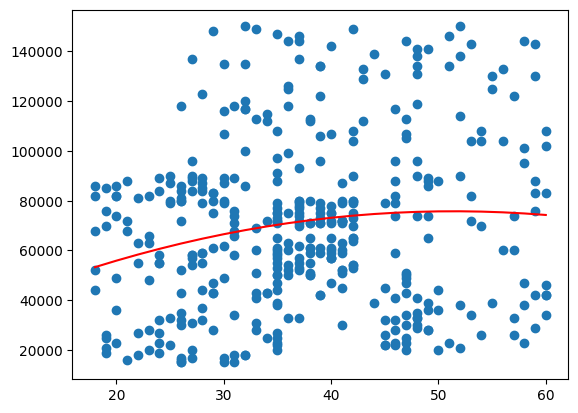

In [32]:
sorted_index = X['Age'].argsort()
X_sorted = X.iloc[sorted_index]
y_pred_sorted = y_pred[sorted_index]

plt.scatter(X, y)
plt.plot(X_sorted, y_pred_sorted, color='red')
plt.show()